In [1]:
from ingestion import ingest, test_ingestion
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from search_query import search_query
from IPython.display import display
from PIL import Image
from dotenv import load_dotenv
load_dotenv()
filepath = "docs/book4.pdf"
model = ChatOpenAI(model="gpt-4o")
embedding_model = OpenAIEmbeddings()

/Users/rajathnagaraj/Documents/youtube-transcript-rag/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ingest
ingest(filepath, model, embedding_model)

Length of chunks after chunking:  23
Ingesting into PGVector...


Collection not found


Ingestion complete


[Document(metadata={'source': 'docs/book4.pdf', 'detection_class_prob': 0.7653807997703552, 'is_extracted': 'true', 'coordinates': {'points': ((np.float64(226.0426788330078), np.float64(315.1598815917969)), (np.float64(226.0426788330078), np.float64(388.6136491513893)), (np.float64(1112.993896484375), np.float64(388.6136491513893)), (np.float64(1112.993896484375), np.float64(315.1598815917969))), 'system': 'PixelSpace', 'layout_width': 2893, 'layout_height': 4094}, 'last_modified': '2026-03-25T02:57:19', 'filetype': 'application/pdf', 'languages': ['eng'], 'page_number': 1, 'file_directory': 'docs', 'filename': 'book4.pdf', 'category': 'NarrativeText', 'element_id': '3991b3a0ac6d751bfb72d187634d00a5'}, page_content='Discuss and write down:'),
 Document(metadata={'source': 'docs/book4.pdf', 'detection_class_prob': 0.6553663611412048, 'is_extracted': 'true', 'coordinates': {'points': ((np.float64(443.8284912109375), np.float64(420.3296770847222)), (np.float64(443.8284912109375), np.float

In [4]:
# optional -> test ingestion
test_ingestion(embedding_model)

Total chunks in DB: 23

Top 3 results for 'Image of O.Henry':

--- Result 1 ---
Category : NarrativeText
Page     : 1
Content  : O. Henry was the pen name of William Sydney Porter. He was born on September 11, 1862 in Greensboro, North Carolina; and he became famous for his short stories. He started The Rolling Stone, a humorou

--- Result 2 ---
Category : NarrativeText
Page     : 1
Content  : O. Henry : 1. Cabbages and Kings

--- Result 3 ---
Category : Image
Page     : 1
Content  : The image is a black and white photograph of a man with a distinct facial appearance. He has a thick mustache and short, wavy hair. The style of his clothing and the photograph's vintage quality sugge

Results with similarity scores:
Score: 0.1364 | Content: O. Henry was the pen name of William Sydney Porter. He was born on September 11, 1862 in Greensboro,
Score: 0.1490 | Content: O. Henry : 1. Cabbages and Kings
Score: 0.1909 | Content: The image is a black and white photograph of a man with a distinct f


Query: Image of O.Henry

Answer:
The rapidity of these movements **is** beyond expectation.

1. The number of visitors **was** really large in the last week’s School Day celebrations.

O. Henry was indeed a notable figure and your description corresponds well with an image of him. O. Henry, born William Sydney Porter, was renowned for his contributions to the short story genre. The vintage photograph you described, depicting a man with a thick mustache and short, wavy hair, likely aligns with historical portraits of O. Henry from the late 19th to early 20th century, aligning with the time he lived and wrote prolifically. His works, such as "Cabbages and Kings" and "The Trimmed Lamp," continue to be appreciated for their wit and creativity.


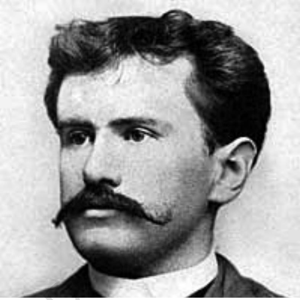

In [5]:
# query the knowledge base
query = input("Enter the query: ")
answer, images = search_query(query, model, embedding_model)

print(f"\nQuery: {query}")
print(f"\nAnswer:\n{answer}")

for image_path in images:
    img = Image.open(image_path)
    img = img.resize((300, 300))  
    display(img)
